In [1]:
import os
from langchain_groq import ChatGroq

os.environ["TAVILY_API_KEY"]=os.getenv("TAVILY_API_KEY")

# Using GROQ API KEY
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")

model = ChatGroq(model="openai/gpt-oss-120b")

In [2]:
from langchain_tavily import TavilySearch

TavilySearch_tool = TavilySearch(
    max_results=5,
    topic="general"
)

In [3]:
TavilySearch_tool.invoke("what is the current AI news for OpenAI")

{'query': 'what is the current AI news for OpenAI',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.wsj.com/topics/subject/openai',
   'title': 'OpenAI - WSJ Spotlight Coverage, Recent News',
   'content': 'By\n\nTech\n\n### OpenAI Pauses Some Work on New AI Model Over Cybersecurity Concerns\n\nThe decision reflects internal findings that the upcoming “Astra” model may possess “critical cyber capabilities” and follows a string of AI-testing incidents.\n\nBy\n\nCIO Journal\n\n### The Summer of Rogue AI Sends a Signal to the Enterprise\n\nA string of AI models escaping testing environments is testing how seriously enterprises take governance.\n\nBy\n\nTech [...] OpenAI is settling claims by the Justice Department that it discriminated against U.S. workers when advertising jobs through its immigration sponsorship program.\n\nBy\n\nand\n\nTech\n\n### OpenAI Calls Apple’s Trade-Secret Suit ‘Careless’ and ‘Oddly Personal’\n\nApple asked the cou

In [4]:
from langchain.tools import tool

@tool("calculator", description="Performs arithmetic calculations. Use this for any math problems.")

def calc(expression: str) -> str:
    """Evaluate mathematical expressions."""
    return str(eval(expression))

In [5]:
from langchain.agents import create_agent

agent=create_agent(model, [TavilySearch_tool,calc])

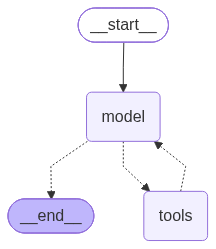

In [6]:
agent

In [7]:
user_input="What is the current AI news  and then calculate 10+18"

for step in agent.stream(
    {
        "messages": [
            ("user", user_input)
        ]
    },
    stream_mode="values"
):
    step["messages"][-1].pretty_print()

================================ Human Message =================================

What is the current AI news  and then calculate 10+18
================================== Ai Message ==================================
Tool Calls:
  tavily_search (fc_96309138-03f7-4374-8d28-218659934e25)
 Call ID: fc_96309138-03f7-4374-8d28-218659934e25
  Args:
    query: latest AI news 2024 August
    search_depth: fast
    time_range: day
================================= Tool Message =================================
Name: tavily_search

{"query": "latest AI news 2024 August", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://breakingai.news/round-up-of-latest-ai-news-13th-august-2024", "title": "Round Up of Latest AI News 13th August 2024 - Breaking AI News", "content": "1. AI in Space Exploration: A student from Southern Utah University, working with NASA, has developed an AI model to assist in mapping craters on Europa, one of Jupiter’s moons. This AI model, bu

In [8]:
from groq import Groq

client = Groq()

models = client.models.list()

for m in models.data:
    print(m.id)

meta-llama/llama-prompt-guard-2-86m
whisper-large-v3-turbo
openai/gpt-oss-20b
qwen/qwen3.6-27b
openai/gpt-oss-safeguard-20b
groq/compound-mini
canopylabs/orpheus-arabic-saudi
canopylabs/orpheus-v1-english
whisper-large-v3
openai/gpt-oss-120b
groq/compound
allam-2-7b
meta-llama/llama-prompt-guard-2-22m
